# 4/24

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 시드 고정 (재현성)
np.random.seed(42)

SGD 데이터를 한개씩 처리. 분류문제에 해당특성이 잘 드러나 있음

In [54]:
X_clf, y_clf = make_classification(
    n_samples=400, n_features=2, random_state=42,
    n_informative=2, n_redundant=0,n_clusters_per_class=1,class_sep=1.5
    )
scaler = StandardScaler()

# 데이터 분할 train - test 8:2
x_train,x_test,y_train,y_test = train_test_split(X_clf,y_clf,random_state=42, stratify=y_clf,test_size=0.2)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# pytorch 텐서로 변환
x_train_t = torch.tensor(x_train,dtype=torch.float32)
y_train_t = torch.FloatTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test)

In [55]:
import torch
import torch.nn as nn

# 시드 고정 (재현성)
np.random.seed(42)

# 분류 모델 정의
# nn.Module 상속
class BinaryClassifier(nn.Module):
  def __init__(self)->None:
    super().__init__()
    self.fc1 = nn.Linear(2 , 16)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(16 ,1 )
    self.sigmoid = nn.Sigmoid()
  def forward(self, x):    
    x = self.relu( self.fc1(x) )    
    output = self.fc2(x)
    return output
  
# 모델 생성
model = BinaryClassifier()
model

BinaryClassifier(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [56]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0)

x_train_dataset = TensorDataset(x_train_t, y_train_t)
x_train_loader = DataLoader(x_train_dataset, batch_size=1, shuffle=True)

In [ ]:
# 훈련 루프
epochs = 100
train_losses, train_accs = [], []

for epoch in range(epochs):
    total_loss, total_acc = 0.0, 0.0
    
    # 데이터 로더
    for x,y in x_train_loader:
        # 1. 가중치 초기화
        optimizer.zero_grad()

        # 2. forward
        predict = model(x).squeeze(0)

        # 3. loss 구하기
        # loss = criterion(predict, y.float())
        loss = criterion(predict, y)

        # 4. backward
        loss.backward()

        # 5. 가중치 업데이트
        optimizer.step()

        total_loss += loss.item()
        # print(torch.sigmoid(predict))
        # total_acc += sum(predict == y) / len(y)
        correct = (predict > 0.5).float() == y
        total_acc += torch.sum(correct).item() / len(y)
    
    train_losses.append(total_loss / len(x_train_loader))
    train_accs.append(total_acc/len(x_train_loader))

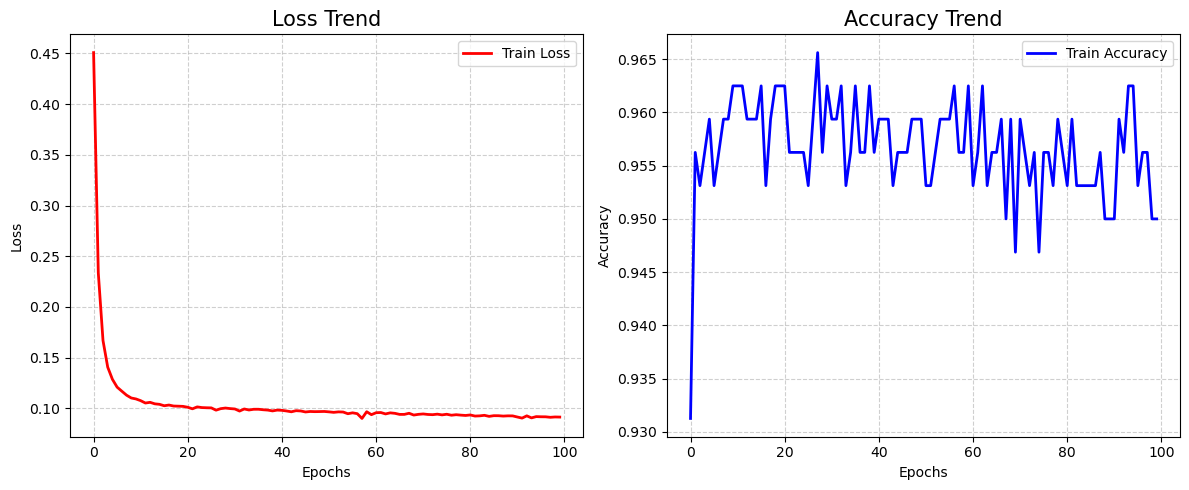

In [59]:
import matplotlib.pyplot as plt

# 1. 그래프 크기 및 스타일 설정
plt.figure(figsize=(12, 5))

# 2. Loss(손실) 그래프
plt.subplot(1, 2, 1) # 1행 2열 중 첫 번째
plt.plot(train_losses, label='Train Loss', color='red', linewidth=2)
plt.title('Loss Trend', fontsize=15)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 3. Accuracy(정확도) 그래프
plt.subplot(1, 2, 2) # 1행 2열 중 두 번째
plt.plot(train_accs, label='Train Accuracy', color='blue', linewidth=2)
plt.title('Accuracy Trend', fontsize=15)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 그래프 간 간격 조절 및 출력
plt.tight_layout()
plt.show()